C:\Users\playdata2\AppData\Local\Temp\ipykernel_4084\4294776185.py:22: DtypeWarning: Columns (0: 층정보) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep=',', encoding='utf-8')


{'욕탕·신체관리', '회계·세무', '본사·경영 컨설팅', '일식', '전문 디자인', '병원', '애완동물·용품 소매', '비알코올 ', '사무 지원', '컴퓨터 수리', '교육 지원', '가전제품 수리', '기타 가정용품 수리', '자동차 부품 소매', '기타 외국', '기타 교육', '기타 간이', '부동산 서비스', '광고', '모터사이클 수리', '가전·통신 소매', '담배 소매', '기타 생활용품 소매', '고용 알선', '이용·미용', '여행사·보조', '철물·건설자재 소매', '기타 개인', '의약·화장품 소매', '장식품 소매', '가정용품 대여', '동남아시아', '기타 보건', '사진 촬영', '오락용품 소매', '기술 서비스', '일반 숙박', '주점', '일반 교육', '인쇄·제품제작', '음료 소매', '법무관련 ', '세탁', '운송장비 대여', '조경·유지', '가구 소매', '기타 사업 서비스', '구내식당·뷔페', '산업용품 대여', '시계·귀금속 소매', '종합 소매', '안경·정밀기기 소매', '연료 소매', '통신장비 수리', '한식', '시장 조사', '중고 상품 소매', '시설관리', '중식', '의원', '수의', '식료품 소매', '기타 숙박', '장례식장 ', '식물 소매', '청소·방제', '모터사이클 소매', '기타 전문 과학', '스포츠 서비스', '서양식', '도서관·사적지', '자동차 수리·세차', '유원지·오락', '섬유·의복·신발 소매', '기타 상품 소매'}
3                    칸토빈
51               빽다방구산역점
78                  맹커피숍
109                   담다
118                   초원
               ...      
537363    스페이스맘(서원안길 합정)
537395        커피앳웍스 센터원점
537425      메이 베이크 커피베이킹
537437     메가엠지씨커피 논현동현점


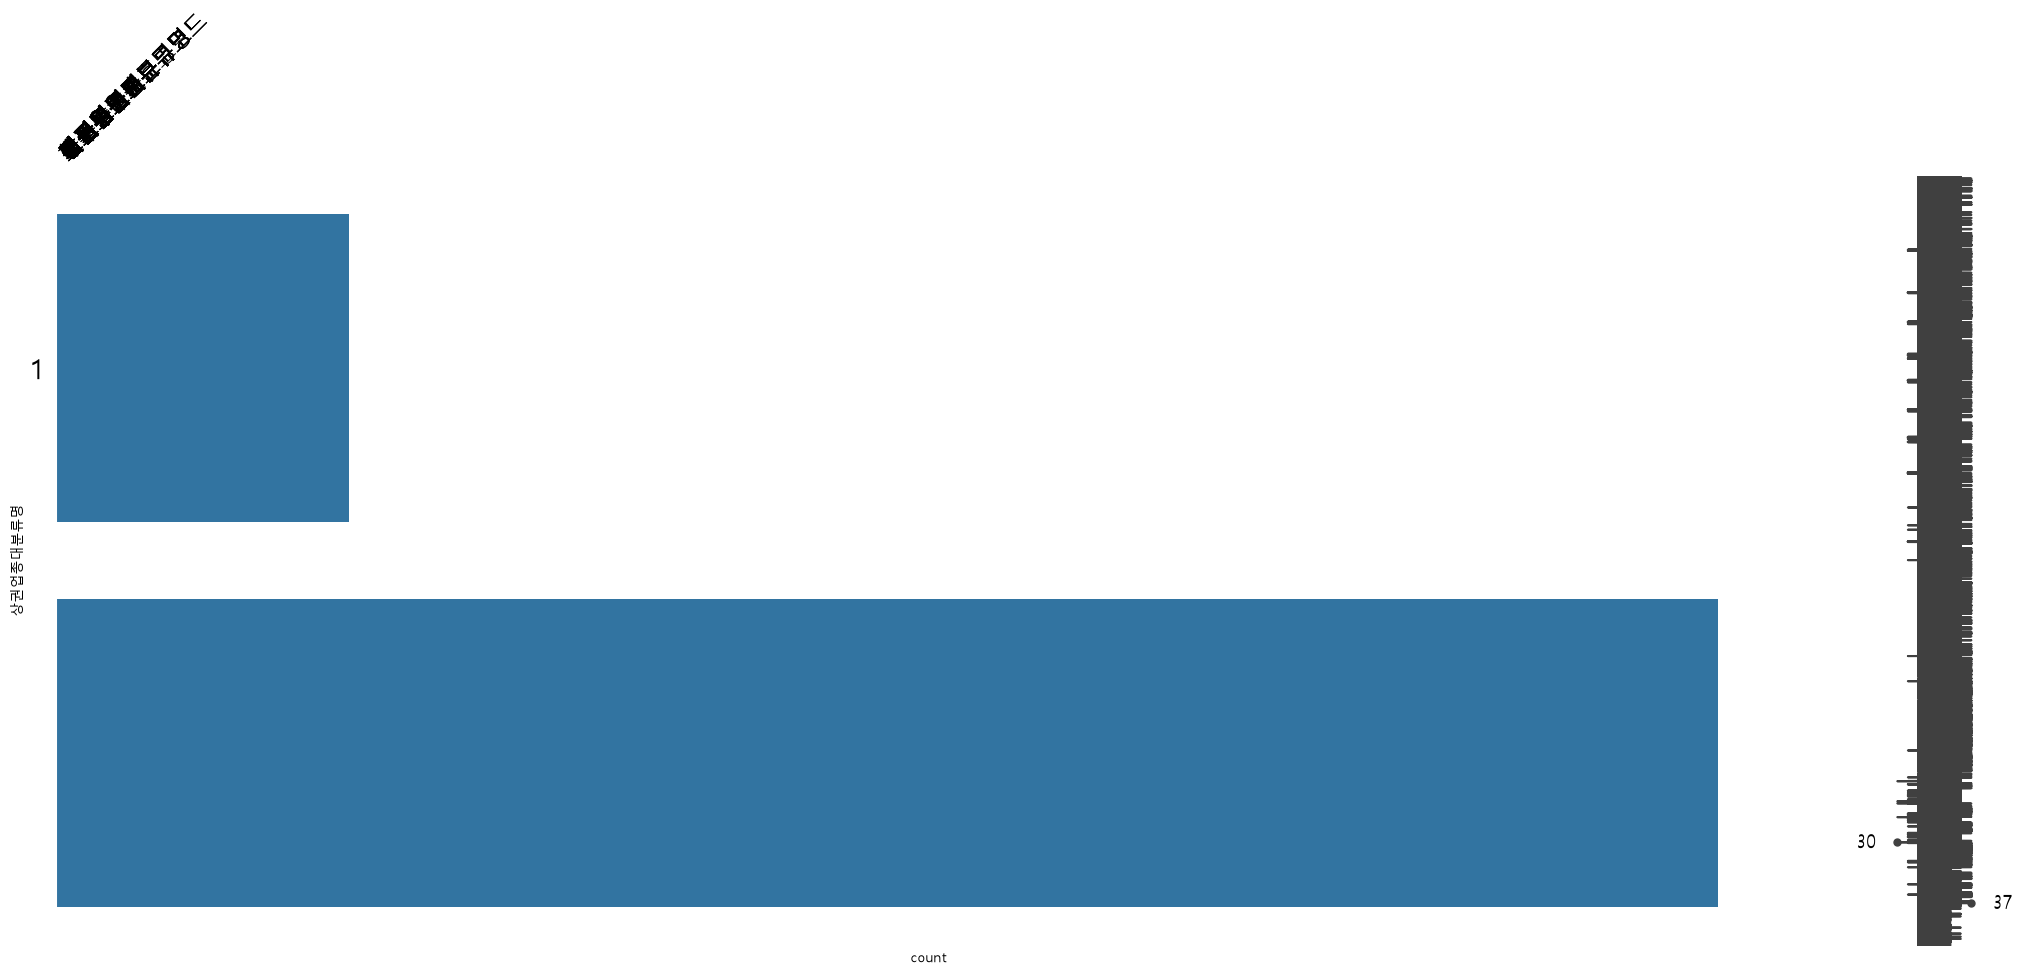

In [7]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import platform

#OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')    # 윈도우 : 맑은고딕
elif platform.system() == 'Darwin':
    plt.rc('forn', family = 'AppleGothic')      # 맥 : 애플고딕
else:
    plt.rc('font', family='NanumbarunGothic')   # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)


# 데이터 파일 불러오기
filepath = 'source/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv'
df = pd.read_csv(filepath, sep=',', encoding='utf-8')
df.head()       # 데이터 파일의 5개 레코드만 샘플로 보여줌

df.shape    # 데이터 추출 개수 확인

df.columns      # 데이터의 컬럼명 확인

set(df['상권업종대분류명'])     # 업종 대분류명확인

print(set(df['상권업종중분류명']))

# 결측치 확인, 갯수 확인
df.isnull().sum()

df.columns      # 컬럼명 확인

# 시도명에서 '서울특별시'만 존재하는지 확인
df['시도명'].unique()

# missingno 설치, missingno 실행 시 오류가 발생하면 설치한다.
# !pip install missingno

# 결측치를 시각화해서 볼 수 있다.
import missingno as msno

# 코랩일 때 사용 명령
# plt.rc)'font', family='NanumBarunGothic')

msno.matrix(df)

df['상권업종대분류명'].value_counts()

df['상권업종중분류명'].value_counts()

sns.countplot(data=df, y='상권업종대분류명')

# df['상권업종대분류명'] == '음식' VS df['상권업종대분류명'].str.contains('음식')
# df[df['상권업종대분류명' == '음식']

df_food = df.loc[df['상권업종대분류명'].str.contains('음식')]
df_food.shape

df_food.head()

df_food['상권업종대분류명'].unique()

sns.countplot(data=df_food, y='상권업종중분류명')

df.columns

# 비연속적인 컬럼의 데이터를 가져올 때 펜시 인덱싱 사용
dataset = df[['상호명','지점명', '상권업종중분류명', '시도명', '시군구명', '행정동명', '도로명', '경도', '위도']]
dataset.head()

# print(dataset['상권업종중분류명'].unique())

# '비알코올' 뒤에 공백이 있으므로 주의하세요
df_coffee = dataset[dataset['상권업종중분류명']=='비알코올 ']   # 데이터값 뒤 부분의 공백 유무에 주의 직접확인
df_coffee.head()

df_coffee['상권업종중분류명'].unique()

print(df_coffee['상호명'])  # 전체 상호명 확인

df_coffee['상호명'].value_counts()      # 상호명별 개수 확인

# 중복된 값 제외, 리스트로 변경, 정렬된 값 확인
print(sorted(list(set(df_coffee['상호명']))))

df_coffee[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA')].shape     # 이디야 개수 확인

df_coffee[df_coffee['상호명'].str.contains('할리스|hollys|HOLLYS')].shape   # 할리스 개수 확인

df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA'), '상호명'].unique()

df_coffee.loc[df_coffee['상호명'].str.contains('할리스|hollys|HOLLYS'), '상호명'].unique()


# 이디야와 할리스 데이터 가져오기
df_coffee_edi_holly = df_coffee.loc[df_coffee['상호명'].str.contains('이디야|ediya|EDIYA|할리스|hollys|HOLLYS')].copy()
df_coffee_edi_holly.shape

df_coffee_edi_holly.sample(5)


# 상호명에 이디야가 포함된 것에 브랜드명 컬럼명을 추가하고 '이디야'을 저장한다. => '브랜드명' 파생변수 생성
df_coffee_edi_holly.loc[df_coffee_edi_holly['상호명'].str.contains('이디야|ediya|EDIYA'), '브랜드명'] = '이디야'

# 상호명에 할리스가 포함된 것에 브랜드명 컬럼명을 추가하고 '할리스'를 저장한다. => '브랜드명' 파생변수 생성
df_coffee_edi_holly.loc[df_coffee_edi_holly['상호명'].str.contains('할리스|hollys|HOLLYS'), '브랜드명'] = '할리스'

df_coffee_edi_holly.sample(5)

df_coffee_edi_holly['브랜드명'].unique()

df_coffee_edi_holly['브랜드명'].value_counts()

geo_df_coffee = df_coffee_edi_holly.copy()

# 지도 마킹 위한 folium 설치
# !pip install folium

import folium

folium.Map

map = folium.Map(location=[geo_df_coffee['위도'].mean(), geo_df_coffee['경도'].mean()],     # 위도와 경도의 평균값을 구함 - mean()
                zoom_start=12, tiles='OpenStreetMap')       # tiles='OpenStreetMap'

for n in geo_df_coffee.index:
    # 팝업에 들어갈 텍스트를 지정해 준다.
    popup_name=geo_df_coffee.loc[n, '상호명'] + ' - '\
    +geo_df_coffee.loc[n, '도로명']

    if geo_df_coffee.loc[n, '브랜드명'] == '이디야':
        icon_color='blue'
    else:
        icon_color='red'

    folium.CircleMarker(
        location=[geo_df_coffee.loc[n, '위도'], geo_df_coffee.loc[n, '경도']],
        radius = 3,
        popup = popup_name,
        color = icon_color,
        fill = True,
        fill_color = icon_color
    ).add_to(map)

    map.save("output/hollys_ediya_store_map_나치훈.html")
    print("저장 완료 : output/hollys_ediya_store_map_나치훈.html")




